In [1]:
import pandas as pd

# Load the file
file_path = 'data.txt'
# Assuming the delimiter is tab based on the content
data = pd.read_csv(file_path, delimiter='\t')

# Save the loaded data as a CSV
csv_path = 'data_converted.csv'
data.to_csv(csv_path, index=False)

Basic Statistics
Min: 0.006778415
Max: 0.015999999
Mean: 0.013155336376629306
Std Dev: 0.0017173014456860192
Median: 0.0133270315



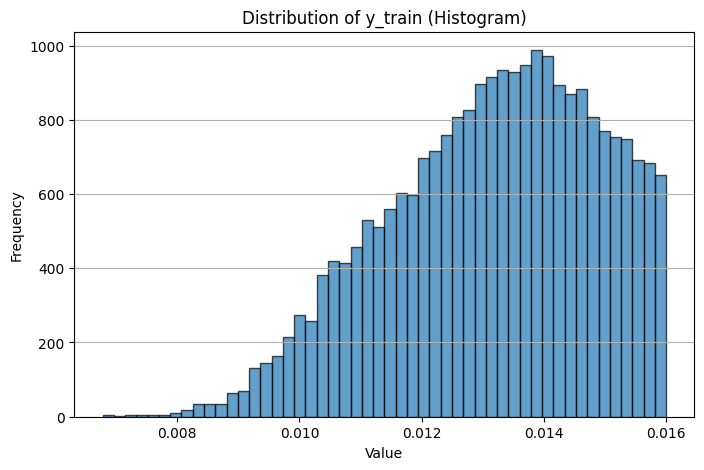

/tmp/ipykernel_1658872/3960505244.py:39: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(y_train, shade=True, color='blue')


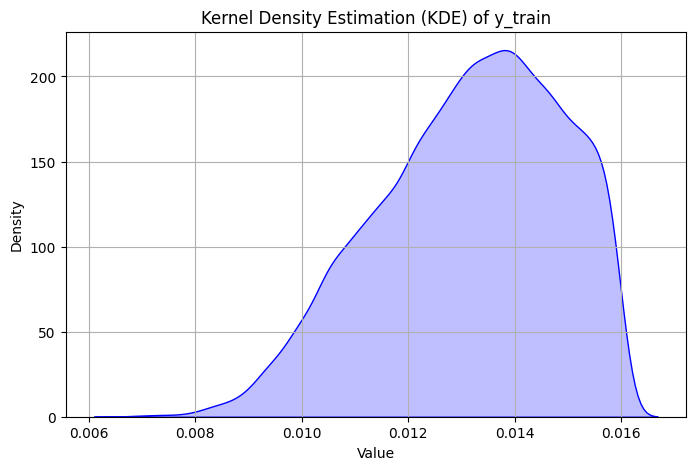

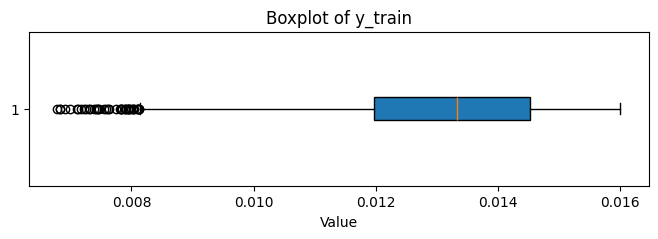

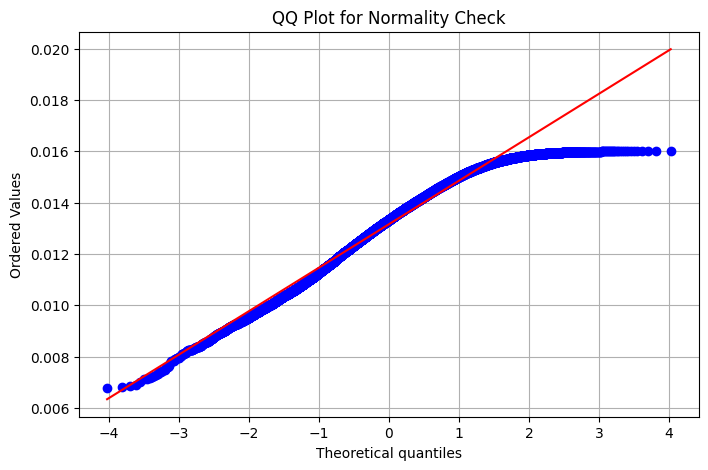

Data Distribution Across Bins:
(0.00678, 0.00862]     122
(0.00862, 0.0105]     1737
(0.0105, 0.0123]      5500
(0.0123, 0.0142]      8976
(0.0142, 0.016]       7754
Name: count, dtype: int64


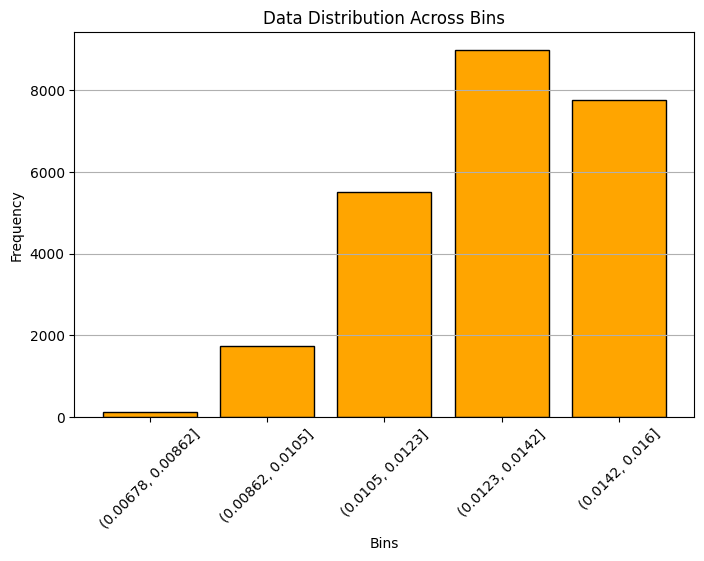

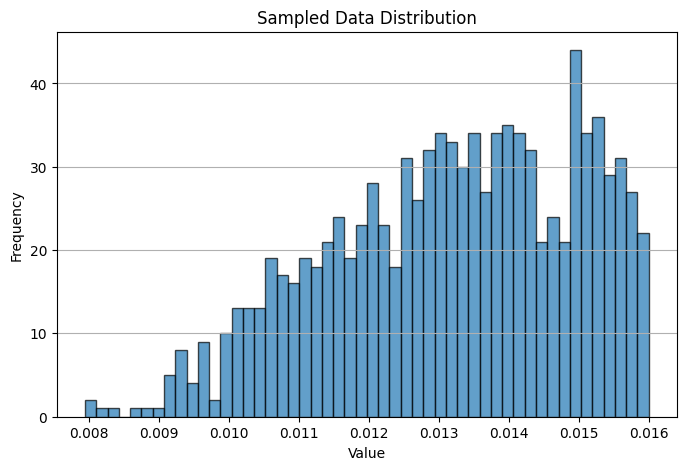

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import probplot

# CSV 파일 경로
csv_file = "data_converted.csv"  # 파일 이름을 실제 경로로 변경하세요.

# 1. CSV 파일에서 데이터 로드
data = pd.read_csv(csv_file)

# 정답값이 있는 열의 이름 (예: 'target', 'label', 'y_train' 등)
target_column = "SFQR_AFS2"  # 열 이름을 변경하세요.

# 2. 정답값 추출
y_train = data[target_column].values

# 3. 기본 통계량 확인
print("Basic Statistics")
print(f"Min: {np.min(y_train)}")
print(f"Max: {np.max(y_train)}")
print(f"Mean: {np.mean(y_train)}")
print(f"Std Dev: {np.std(y_train)}")
print(f"Median: {np.median(y_train)}")
print()

# 4. 히스토그램
plt.figure(figsize=(8, 5))
plt.hist(y_train, bins=50, edgecolor='k', alpha=0.7)
plt.title("Distribution of y_train (Histogram)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.grid(axis='y')
plt.show()

# 5. 커널 밀도 추정 (KDE)
plt.figure(figsize=(8, 5))
sns.kdeplot(y_train, shade=True, color='blue')
plt.title("Kernel Density Estimation (KDE) of y_train")
plt.xlabel("Value")
plt.ylabel("Density")
plt.grid()
plt.show()

# 6. 박스플롯
plt.figure(figsize=(8, 2))
plt.boxplot(y_train, vert=False, patch_artist=True)
plt.title("Boxplot of y_train")
plt.xlabel("Value")
plt.show()

# 7. QQ Plot (정규성 확인)
plt.figure(figsize=(8, 5))
probplot(y_train, dist="norm", plot=plt)
plt.title("QQ Plot for Normality Check")
plt.grid()
plt.show()

# 8. 구간별 데이터 분포 확인
bins = np.linspace(np.min(y_train), np.max(y_train), 6)  # 최소값~최대값 기준으로 5개 구간 생성
categories = pd.cut(y_train, bins=bins)
distribution = categories.value_counts().sort_index()
print("Data Distribution Across Bins:")
print(distribution)

# 시각화
plt.figure(figsize=(8, 5))
plt.bar(distribution.index.astype(str), distribution.values, color='orange', edgecolor='k')
plt.title("Data Distribution Across Bins")
plt.xlabel("Bins")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

# 9. 샘플링한 데이터 분포 확인
sampled_data = np.random.choice(y_train, size=min(1000, len(y_train)), replace=False)

plt.figure(figsize=(8, 5))
plt.hist(sampled_data, bins=50, edgecolor='k', alpha=0.7)
plt.title("Sampled Data Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.grid(axis='y')
plt.show()


Mean: 0.013155336376629306
Std Dev: 0.0017173014456860192

Shapiro-Wilk Test:
Statistic: 0.9733228565728179, p-value: 9.907924461345452e-54

D’Agostino and Pearson’s Test:
Statistic: 1095.1300202257073, p-value: 1.568691793915104e-238

Anderson-Darling Test:
Statistic: 143.21596159025648
Critical Values: [0.576 0.656 0.787 0.918 1.092]
Significance Levels: [15.  10.   5.   2.5  1. ]


/raid/lee/anaconda3/envs/2024/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 24090.
  res = hypotest_fun_out(*samples, **kwds)


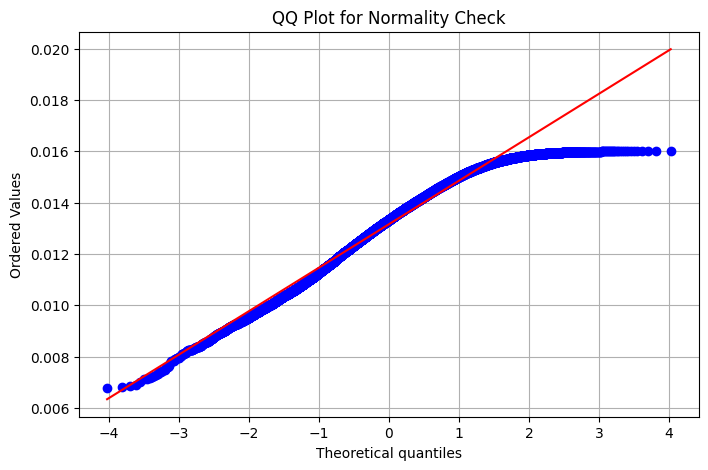

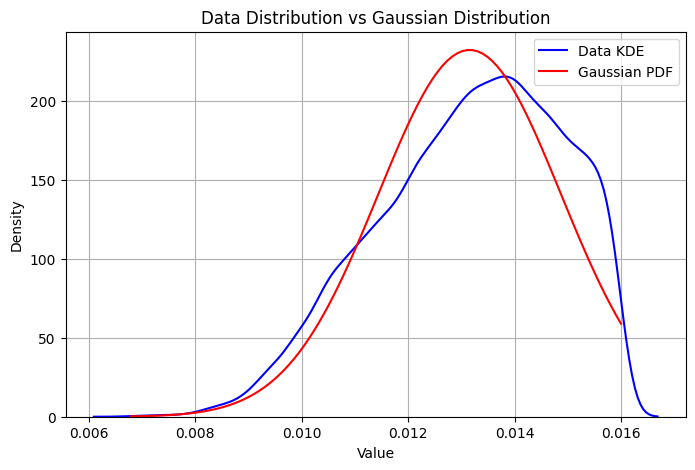

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, normaltest, anderson, probplot, norm

# CSV 파일 로드
csv_path = 'data_converted.csv'  # 파일 경로
data = pd.read_csv(csv_path)

# 분석할 대상 열 지정 (예: 'SFQR_AFS2')
target_column = 'SFQR_AFS2'  # 열 이름 변경 필요
y_train = data[target_column]

# 1. 기본 통계량 출력
mean = np.mean(y_train)
std = np.std(y_train)
print(f"Mean: {mean}")
print(f"Std Dev: {std}")

# 2. 정규성 테스트
print("\nShapiro-Wilk Test:")
stat, p = shapiro(y_train)
print(f"Statistic: {stat}, p-value: {p}")

print("\nD’Agostino and Pearson’s Test:")
stat, p = normaltest(y_train)
print(f"Statistic: {stat}, p-value: {p}")

print("\nAnderson-Darling Test:")
result = anderson(y_train)
print(f"Statistic: {result.statistic}")
print("Critical Values:", result.critical_values)
print("Significance Levels:", result.significance_level)

# 3. QQ Plot
plt.figure(figsize=(8, 5))
probplot(y_train, dist="norm", plot=plt)
plt.title("QQ Plot for Normality Check")
plt.grid()
plt.show()

# 4. 데이터 분포와 가우시안 분포 비교
plt.figure(figsize=(8, 5))
sns.kdeplot(y_train, label='Data KDE', color='blue')
x = np.linspace(min(y_train), max(y_train), 100)
gaussian_pdf = norm.pdf(x, mean, std)
plt.plot(x, gaussian_pdf, label='Gaussian PDF', color='red')
plt.title("Data Distribution vs Gaussian Distribution")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.grid()
plt.show()


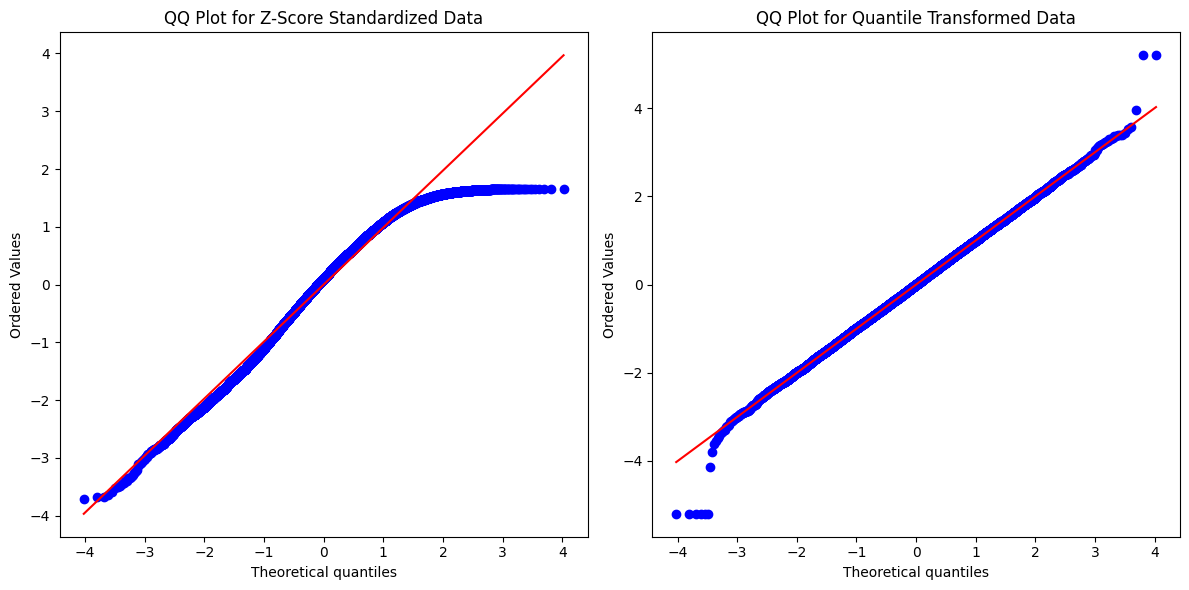

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import QuantileTransformer
from scipy.stats import probplot

# Load the data from CSV
csv_path = 'CENC16B.csv'
data = pd.read_csv(csv_path)

# Extract the target column
target_column = 'SFQR_AFS2'  # Replace with the actual column name if different
y_train = data[target_column].values

# 5. Z-Score Standardization
y_zscore = (y_train - np.mean(y_train)) / np.std(y_train)

# 6. Quantile Transformation
quantile_transformer = QuantileTransformer(output_distribution='normal', random_state=42)
y_quantile_transformed = quantile_transformer.fit_transform(y_train.reshape(-1, 1)).flatten()

# Plot QQ plots for both transformations
plt.figure(figsize=(12, 6))

# QQ Plot for Z-Score Standardized Data
plt.subplot(1, 2, 1)
probplot(y_zscore, dist="norm", plot=plt)
plt.title("QQ Plot for Z-Score Standardized Data")

# QQ Plot for Quantile Transformed Data
plt.subplot(1, 2, 2)
probplot(y_quantile_transformed, dist="norm", plot=plt)
plt.title("QQ Plot for Quantile Transformed Data")

plt.tight_layout()
plt.show()


In [8]:
# Z-Score 복원
y_restored_zscore = y_zscore * np.std(y_train) + np.mean(y_train)

# Quantile Transformation 복원
y_restored_quantile = quantile_transformer.inverse_transform(y_quantile_transformed.reshape(-1, 1)).flatten()

# 복원된 값 확인
print("Z-Score 복원된 값 예시:", y_restored_zscore[:5])
print("Quantile Transformation 복원된 값 예시:", y_restored_quantile[:5])


Z-Score 복원된 값 예시: [0.01314175 0.01402295 0.01395248 0.01482357 0.01141449]
Quantile Transformation 복원된 값 예시: [0.01314175 0.01402295 0.01395248 0.01482357 0.01141449]


In [42]:
y_quantile_transformed

array([-0.10155965,  0.38653444,  0.34399477, ...,  1.10174752,
        1.71065845,  2.12485466])

In [43]:
y_quantile_transformed.reshape(-1, 1)

array([[-0.10155965],
       [ 0.38653444],
       [ 0.34399477],
       ...,
       [ 1.10174752],
       [ 1.71065845],
       [ 2.12485466]])

In [18]:
import os
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm import tqdm
from torch.utils.tensorboard import SummaryWriter
from einops import rearrange, reduce

# 1. 데이터 매핑 함수
def map_to_numeric(values):
    mapping = {val: idx for idx, val in enumerate(sorted(values))}
    return mapping

# 2. Custom Dataset 정의
class CustomDataset(Dataset):
    def __init__(self, df):
        self.data = df
        self.filtered_data = self.data[self.data['STEP_NAME'] == 'DEPO']
        self.labels = self.filtered_data['SFQR_AFS2'].values
        self.quantile_transformer = QuantileTransformer(output_distribution='normal', random_state=42)
        self.labels = self.quantile_transformer.fit_transform(self.labels.reshape(-1, 1)).flatten()
        self.features = self.filtered_data.drop(columns=['SFQR_AFS2', 'STEP_NAME', "WAF_ID", "HST_REG_DTTM", 'STEP_ID']).values

    def __len__(self):
        return len(self.filtered_data)

    def __getitem__(self, idx):
        return torch.tensor(self.features[idx], dtype=torch.float32), torch.tensor(self.labels[idx], dtype=torch.float32)

# 3. Transformer 모델 정의
class FullMultiLevelTransformer(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.1):
        super(FullMultiLevelTransformer, self).__init__()
        self.d_model = d_model

        self.feature_embedding = nn.Linear(input_dim, d_model)
        self.feature_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, dropout=dropout),
            num_layers=num_layers
        )
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.feature_embedding(x)
        x = rearrange(x, 'b d -> b 1 d')
        x = self.feature_transformer(x)
        x = reduce(x, 'b 1 d -> b d', 'mean')
        return self.fc(x)

# 4. MSE Loss
def mse_loss(output, target):
    return torch.mean((output - target) ** 2)

# 5. Accuracy 계산
def calculate_accuracy(output, target, threshold=0.0001):
    correct = torch.abs(output - target) <= threshold
    return correct.sum().item() / len(target)

# 6. Train/Val Split
def train_val_split(dataset, val_ratio=0.2):
    val_size = int(len(dataset) * val_ratio)
    train_size = len(dataset) - val_size
    return random_split(dataset, [train_size, val_size])

# 7. 모델 훈련 루프
def train_model_with_masked_inputs(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, log_dir, save_path):
    writer = SummaryWriter(log_dir)
    model.to(device)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        total_accuracy = 0.0

        for batch_data, batch_labels in tqdm(train_loader, desc=f"Training Epoch {epoch + 1}/{num_epochs}"):
            batch_data, batch_labels = batch_data.to(device), batch_labels.to(device)

            outputs = model(batch_data)

            loss = criterion(outputs.squeeze(), batch_labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            accuracy = calculate_accuracy(outputs.squeeze(), batch_labels)
            total_accuracy += accuracy

        avg_train_loss = running_loss / len(train_loader)
        avg_train_accuracy = total_accuracy / len(train_loader)
        writer.add_scalar("Loss/Train", avg_train_loss, epoch)
        writer.add_scalar("Accuracy/Train", avg_train_accuracy, epoch)
        print(f"Epoch [{epoch + 1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Train Accuracy: {avg_train_accuracy:.4f}")

        # Validation Step
        model.eval()
        val_loss = 0.0
        val_accuracy = 0.0
        with torch.no_grad():
            for batch_data, batch_labels in val_loader:
                batch_data, batch_labels = batch_data.to(device), batch_labels.to(device)
                outputs = model(batch_data)
                # print(outputs[0], batch_labels[0])
                loss = criterion(outputs.squeeze(), batch_labels)
                val_loss += loss.item()

                accuracy = calculate_accuracy(outputs.squeeze(), batch_labels)
                val_accuracy += accuracy

        avg_val_loss = val_loss / len(val_loader)
        avg_val_accuracy = val_accuracy / len(val_loader)
        writer.add_scalar("Loss/Validation", avg_val_loss, epoch)
        writer.add_scalar("Accuracy/Validation", avg_val_accuracy, epoch)
        print(f"Epoch [{epoch + 1}/{num_epochs}], Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {avg_val_accuracy:.4f}")

    writer.close()
    # 모델 가중치 저장
    torch.save(model.state_dict(), save_path)
    print(f"Model weights saved to {save_path}")

# 8. 테스트 함수
def test_model(model, test_loader, device, load_path):
    model.load_state_dict(torch.load(load_path))
    model.to(device)
    model.eval()

    predictions = []
    true_labels = []
    with torch.no_grad():
        for batch_data, batch_labels in tqdm(test_loader, desc="Testing"):
            batch_data = batch_data.to(device)
            # print(batch_data.shape)
            outputs = model(batch_data).squeeze()
            predictions.extend(outputs)
            true_labels.extend(batch_labels)

    return predictions, true_labels

# 9. Main 실행
def main():
    RECIPE_ID = {'CAN3_01_CA', 'CAN3_01_CB', 'CIS_CA', 'CIS_CB', 'CIS_P+_CA', 'CIS_P+_CB', 'CIS_P+_CXT5_CB', 'CIS_P+_GLX5_CA', 'CIS_P+_GLX5_CB', 'CIS_P+_HUA4_CA', 'CIS_P+_HUA4_CB', 'CIS_P+_ICR5_CB', 'CIS_P+_ONS6_CA', 'CIS_P+_ONS6_CB', 'CIS_P+_PSM4_CA', 'CIS_P+_SKH6_CA', 'CIS_P+_SKH6_CB', 'CIS_P+_SKH9_CA',
    'CIS_P+_SKH9_CB', 'CIS_P+_SMI4_CA', 'CIS_P+_UMC4_CA', 'CIS_P+_UMC4_CB', 'CIS_P_SKH6_CA', 'CIS_P_SKH6_CB', 'GF_01_CA', 'GF_01_CB', 'GF_02_CA', 'GF_02_CB', 'GF_03_CA', 'GF_03_CB', 'HUALI_01_CA', 'HUALI_01_CB',
    'INTEL10_CA', 'INTEL10_CB', 'INTEL14_CB', 'INTEL2_CA', 'INTEL2_CB', 'INTEL7_CA', 'INTEL7_CB', 'L2_CB', 'LOG_TSM1_CA', 'LOG_TSM1_CB', 'LOG_TSM3_CA', 'LOG_TSM3_CB', 'MIC_01_CA', 'MIC_01_CB', 'MXIC_01_CA', 'MXIC_01_CB', 'PSMC_02_CA', 'PSMC_02_CB', 'PSMC_FSI_CA', 'S14_CA', 'S14_CB', 'SEC_L58_CA', 'SEC_L58_CB',
    'SKH_CIS_CA', 'SKH_CIS_P+_CA', 'SKH_CIS_P+_CB', 'SL_CA', 'SL_CB', 'SMIC2_R0_CA', 'SMIC2_R0_CB', 'SMIC4_R0_CA', 'SMIC_L7_CB', 'STM_01_CA', 'STM_01_CB', 'STM_P+_CA', 'STM_P+_CB', 'TIX_R0_CA', 'TIX_R0_CB', 'TIX_R1_CA', 'TIX_R1_CB', 'TSMC2_CA', 'TSMC2_CB', 'TSMC_CA', 'TSMC_CB', 'UMC_R0_CA', 'UMC_R0_CB'}

    EQP_ID_MODULE_NAME = {'CENC10A', 'CENC10B', 'CENC11A', 'CENC11B', 'CENC12A', 'CENC12B', 'CENC13A', 'CENC13B', 'CENC14A', 'CENC14B', 'CENC15A', 'CENC15B', 'CENC16A', 'CENC16B', 'CENC17A', 'CENC17B', 'CENC31A', 'CENC31B', 'CENC32A',
    'CENC32B', 'CENC33A', 'CENC33B', 'CENC34A', 'CENC34B', 'CENC35A', 'CENC35B', 'CENC36A', 'CENC36B', 'CENC41A', 'CENC41B', 'CENC42A', 'CENC42B', 'CENC43A', 'CENC43B', 'CENC44A', 'CENC44B', 'CENC45A', 'CENC45B',
    'CENC46A', 'CENC46B', 'CENC47A', 'CENC47B', 'CENC48A', 'CENC48B', 'CENC5A', 'CENC5B', 'CENC6A', 'CENC6B', 'CENC7A', 'CENC7B', 'CENC8A', 'CENC8B', 'CENC9A', 'CENC9B', 'ZCENC01A', 'ZCENC01B', 'ZCENC02A', 'ZCENC02B',
    'ZCENC03A', 'ZCENC03B', 'ZCENC04A', 'ZCENC04B'}

    recipe_mapping = map_to_numeric(RECIPE_ID)
    eqp_mapping = map_to_numeric(EQP_ID_MODULE_NAME)

    # 6. Quantile Transformation

    # Load CSV
    csv_file = 'CENC16B.csv'
    df = pd.read_csv(csv_file)

    df = df.dropna(axis=0)

    # Ensure HST_REG_DTTM is sorted
    df = df.sort_values("HST_REG_DTTM")

    # Replace RECIPE_ID and EQP_ID_MODULE_NAME with numeric values
    if "RECIPE_ID" in df.columns:
        df["RECIPE_ID"] = df["RECIPE_ID"].map(recipe_mapping)
    if "EQP_ID_MODULE_NAME" in df.columns:
        df["EQP_ID_MODULE_NAME"] = df["EQP_ID_MODULE_NAME"].map(eqp_mapping)

    dataset = CustomDataset(df)
    train_dataset, val_dataset = train_val_split(dataset, val_ratio=0.2)
    train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)

    # 모델 및 학습 설정
    model = FullMultiLevelTransformer(input_dim=33, d_model=256, nhead=4, num_layers=2, dim_feedforward=512)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    save_path = "model_weights.pth"
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # train_model_with_masked_inputs(
    #     model=model,
    #     train_loader=train_loader,
    #     val_loader=val_loader,
    #     criterion=mse_loss,
    #     optimizer=optimizer,
    #     num_epochs=2000,
    #     device=device,
    #     log_dir="logs",
    #     save_path=save_path
    # )

    train_model_with_masked_inputs(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=nn.HuberLoss(delta=1.0),
        optimizer=optimizer,
        num_epochs=400,
        device=device,
        log_dir="logs",
        save_path=save_path
    )


    # 테스트 데이터셋 생성
    test_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
    predictions, true_labels = test_model(model, test_loader, device, save_path)

    print("Test completed. Predictions and labels collected.")

if __name__ == "__main__":
    main()

/raid/lee/anaconda3/envs/2024/lib/python3.11/site-packages/torch/nn/modules/transformer.py:306: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
Training Epoch 1/400: 100%|████████████████████| 38/38 [00:00<00:00, 119.89it/s]


Epoch [1/400], Train Loss: 0.6214, Train Accuracy: 0.0000
Epoch [1/400], Validation Loss: 0.4299, Validation Accuracy: 0.0000


Training Epoch 2/400: 100%|█████████████████████| 38/38 [00:00<00:00, 90.67it/s]


Epoch [2/400], Train Loss: 0.4155, Train Accuracy: 0.0001
Epoch [2/400], Validation Loss: 0.4035, Validation Accuracy: 0.0004


Training Epoch 3/400: 100%|████████████████████| 38/38 [00:00<00:00, 139.61it/s]


...

Epoch [399/400], Train Loss: 0.2629, Train Accuracy: 0.0000
Epoch [399/400], Validation Loss: 0.2740, Validation Accuracy: 0.0000


Training Epoch 400/400: 100%|██████████████████| 38/38 [00:00<00:00, 133.20it/s]


Epoch [400/400], Train Loss: 0.2607, Train Accuracy: 0.0001
Epoch [400/400], Validation Loss: 0.2773, Validation Accuracy: 0.0002
Model weights saved to model_weights.pth


Testing: 100%|█████████████████████████████████| 10/10 [00:00<00:00, 196.40it/s]

Test completed. Predictions and labels collected.


/raid/lee/anaconda3/envs/2024/lib/python3.11/site-packages/torch/nn/modules/transformer.py:306: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
Testing: 100%|█████████████████████████████████| 10/10 [00:00<00:00, 140.42it/s]


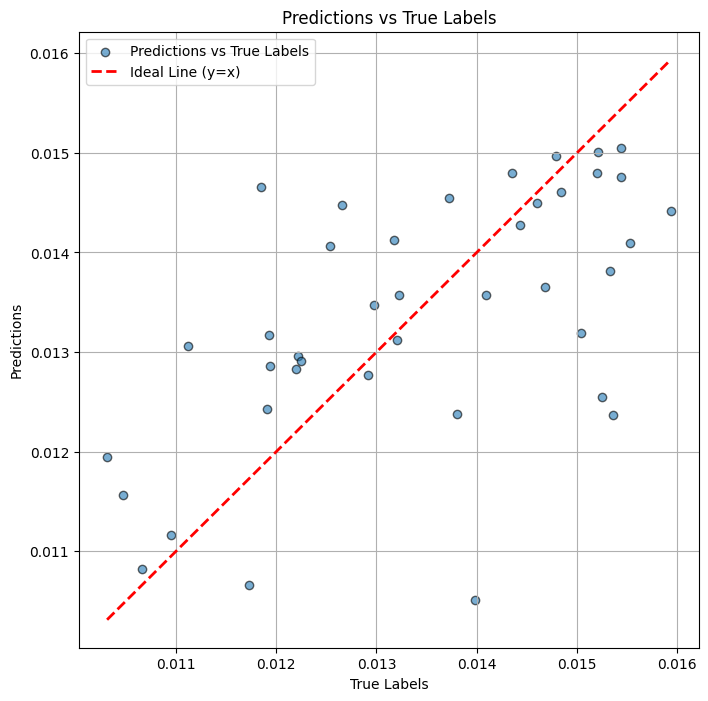

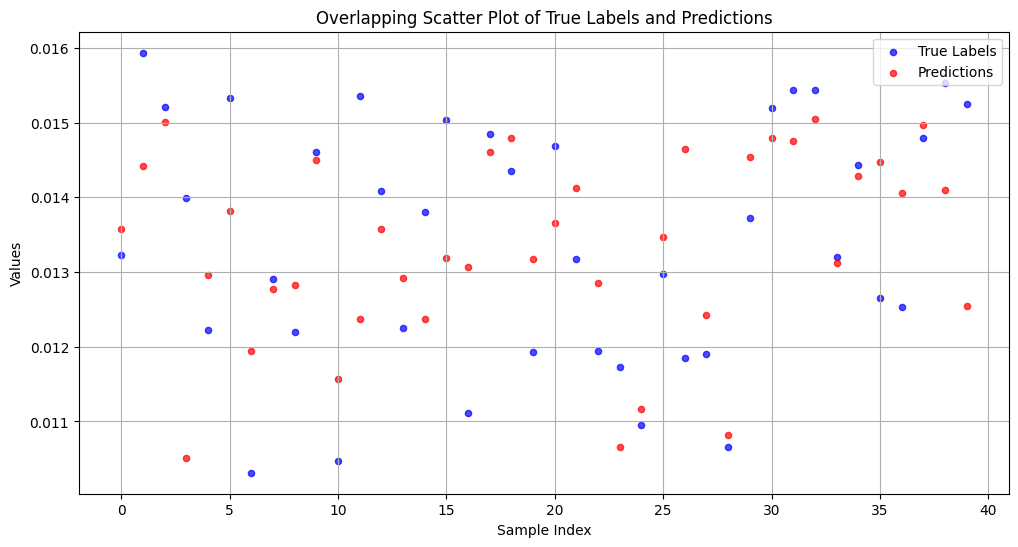

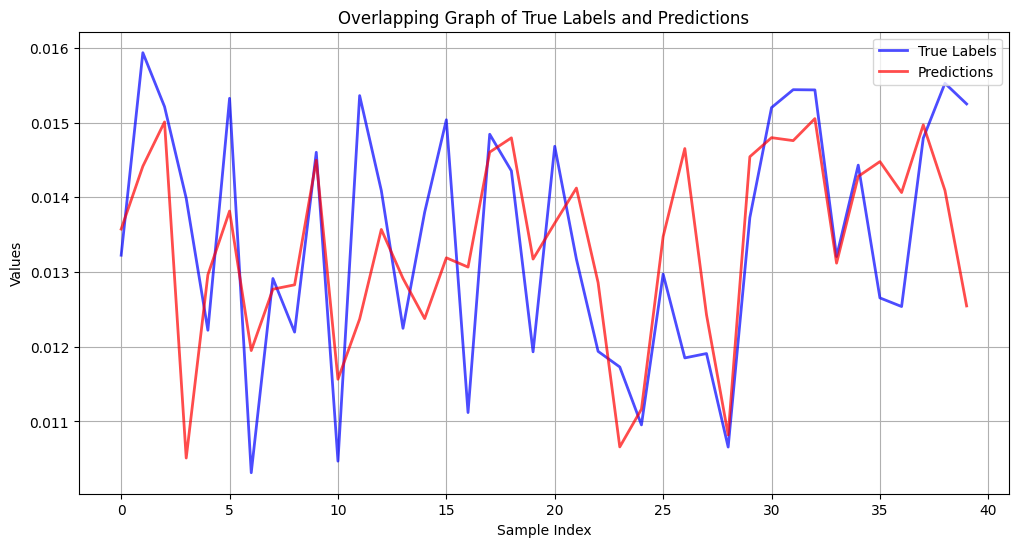

Correlation Coefficient (True Labels vs Predictions): 0.5916
0.5916068292931238


In [70]:
import os
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import QuantileTransformer
from torch.utils.data import Dataset, DataLoader, random_split


# 데이터 매핑 함수
def map_to_numeric(values):
    return {val: idx for idx, val in enumerate(sorted(values))}


# Custom Dataset 정의
class CustomDataset(Dataset):
    def __init__(self, df):
        self.data = df
        self.filtered_data = self.data[self.data['STEP_NAME'] == 'DEPO']
        self.labels = self.filtered_data['SFQR_AFS2'].values
        self.quantile_transformer = QuantileTransformer(output_distribution='normal', random_state=42)
        self.labels = self.quantile_transformer.fit_transform(self.labels.reshape(-1, 1)).flatten()
        self.features = self.filtered_data.drop(
            columns=['SFQR_AFS2', 'STEP_NAME', "WAF_ID", "HST_REG_DTTM", 'STEP_ID']
        ).values

    def __len__(self):
        return len(self.filtered_data)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.features[idx], dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.float32),
        )


# Transformer 모델 정의
class FullMultiLevelTransformer(torch.nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=6, dim_feedforward=128):
        super(FullMultiLevelTransformer, self).__init__()
        self.feature_embedding = torch.nn.Linear(input_dim, d_model)
        self.feature_transformer = torch.nn.TransformerEncoder(
            torch.nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward),
            num_layers=num_layers,
        )
        self.fc = torch.nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.feature_embedding(x)
        x = x.unsqueeze(1)  # (batch_size, seq_len=1, d_model)
        x = self.feature_transformer(x)
        x = x.mean(dim=1)  # (batch_size, d_model)
        return self.fc(x)


# 손실 함수
def mse_loss(output, target):
    return torch.mean((output - target) ** 2)


# 정확도 계산 함수
def calculate_accuracy(output, target, threshold=0.001):
    correct = torch.abs(output - target) <= threshold
    return correct.sum().item() / len(target)


# Train/Validation Split
def train_val_split(dataset, val_ratio=0.2):
    val_size = int(len(dataset) * val_ratio)
    train_size = len(dataset) - val_size
    return random_split(dataset, [train_size, val_size])


# 테스트 함수
def test_model(model, test_loader, device, load_path, quantile_transformer):
    model.load_state_dict(torch.load(load_path))
    model.to(device)
    model.eval()
    predictions = []
    true_labels = []
    with torch.no_grad():
        for batch_data, batch_labels in tqdm(test_loader, desc="Testing"):
            batch_data = batch_data.to(device)
            batch_labels = batch_labels.to(device)
            outputs = model(batch_data).squeeze()
            predictions.extend(outputs.cpu().numpy())
            true_labels.extend(batch_labels.cpu().numpy())
    return predictions, true_labels


# 그래프 출력 함수
def plot_predictions(predictions, true_labels, quantile_transformer):
    """
    예측값과 실제값을 비교하는 산점도 생성
    """
    # 예측값 및 정답값 복원
    predictions = torch.tensor(predictions).detach().cpu().numpy().reshape(-1, 1)
    predictions = quantile_transformer.inverse_transform(predictions).flatten()
    true_labels = torch.tensor(true_labels).detach().cpu().numpy().reshape(-1, 1)
    true_labels = quantile_transformer.inverse_transform(true_labels).flatten()

    # 산점도 생성
    plt.figure(figsize=(8, 8))
    plt.scatter(true_labels, predictions, alpha=0.6, edgecolor="k", label="Predictions vs True Labels")
    plt.plot(
        [min(true_labels), max(true_labels)],
        [min(true_labels), max(true_labels)],
        'r--', lw=2, label="Ideal Line (y=x)"
    )
    plt.title("Predictions vs True Labels")
    plt.xlabel("True Labels")
    plt.ylabel("Predictions")
    plt.legend(loc="upper left")
    plt.grid(True)
    plt.show()

def plot_overlapping_results_with_points(predictions, true_labels, quantile_transformer):
    """
    정답값과 예측값을 동일한 그래프에 점으로 겹쳐서 표시
    """
    # 예측값 및 정답값 복원
    predictions = torch.tensor(predictions).detach().cpu().numpy().reshape(-1, 1)
    predictions = quantile_transformer.inverse_transform(predictions).flatten()
    true_labels = torch.tensor(true_labels).detach().cpu().numpy().reshape(-1, 1)
    true_labels = quantile_transformer.inverse_transform(true_labels).flatten()

    # 그래프 생성
    plt.figure(figsize=(12, 6))
    plt.scatter(range(len(true_labels)), true_labels, label="True Labels", color="blue", alpha=0.7, s=20)
    plt.scatter(range(len(predictions)), predictions, label="Predictions", color="red", alpha=0.7, s=20)
    
    # 그래프 설정
    plt.title("Overlapping Scatter Plot of True Labels and Predictions")
    plt.xlabel("Sample Index")
    plt.ylabel("Values")
    plt.legend(loc="upper right")
    plt.grid(True)
    plt.show()

def plot_overlapping_results(predictions, true_labels, quantile_transformer):
    """
    정답값과 예측값을 동일한 그래프에 겹쳐서 표시
    """
    # 예측값 및 정답값 복원
    predictions = torch.tensor(predictions).detach().cpu().numpy().reshape(-1, 1)
    predictions = quantile_transformer.inverse_transform(predictions).flatten()
    true_labels = torch.tensor(true_labels).detach().cpu().numpy().reshape(-1, 1)
    true_labels = quantile_transformer.inverse_transform(true_labels).flatten()

    # 그래프 생성
    plt.figure(figsize=(12, 6))
    plt.plot(true_labels, label="True Labels", color="blue", linewidth=2, alpha=0.7)
    plt.plot(predictions, label="Predictions", color="red", linewidth=2, alpha=0.7)
    
    # 그래프 설정
    plt.title("Overlapping Graph of True Labels and Predictions")
    plt.xlabel("Sample Index")
    plt.ylabel("Values")
    plt.legend(loc="upper right")
    plt.grid(True)
    plt.show()

def calculate_correlation(predictions, true_labels, quantile_transformer):
    """
    정답값과 예측값의 상관관계를 계산
    """
    # 예측값 및 정답값 복원
    predictions = torch.tensor(predictions).detach().cpu().numpy().reshape(-1, 1)
    predictions = quantile_transformer.inverse_transform(predictions).flatten()
    true_labels = torch.tensor(true_labels).detach().cpu().numpy().reshape(-1, 1)
    true_labels = quantile_transformer.inverse_transform(true_labels).flatten()

    # 상관계수 계산
    correlation = np.corrcoef(true_labels, predictions)[0, 1]
    print(f"Correlation Coefficient (True Labels vs Predictions): {correlation:.4f}")
    return correlation


# Main 실행
def main():
    # 데이터 경로 설정
    csv_file = 'CENC16B.csv'  # 실제 CSV 파일 경로로 변경하세요
    save_path = "model_weights.pth"  # 모델 가중치 경로 설정
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    RECIPE_ID = {'CAN3_01_CA', 'CAN3_01_CB', 'CIS_CA', 'CIS_CB', 'CIS_P+_CA', 'CIS_P+_CB', 'CIS_P+_CXT5_CB', 'CIS_P+_GLX5_CA', 'CIS_P+_GLX5_CB', 'CIS_P+_HUA4_CA', 'CIS_P+_HUA4_CB', 'CIS_P+_ICR5_CB', 'CIS_P+_ONS6_CA', 'CIS_P+_ONS6_CB', 'CIS_P+_PSM4_CA', 'CIS_P+_SKH6_CA', 'CIS_P+_SKH6_CB', 'CIS_P+_SKH9_CA',
    'CIS_P+_SKH9_CB', 'CIS_P+_SMI4_CA', 'CIS_P+_UMC4_CA', 'CIS_P+_UMC4_CB', 'CIS_P_SKH6_CA', 'CIS_P_SKH6_CB', 'GF_01_CA', 'GF_01_CB', 'GF_02_CA', 'GF_02_CB', 'GF_03_CA', 'GF_03_CB', 'HUALI_01_CA', 'HUALI_01_CB',
    'INTEL10_CA', 'INTEL10_CB', 'INTEL14_CB', 'INTEL2_CA', 'INTEL2_CB', 'INTEL7_CA', 'INTEL7_CB', 'L2_CB', 'LOG_TSM1_CA', 'LOG_TSM1_CB', 'LOG_TSM3_CA', 'LOG_TSM3_CB', 'MIC_01_CA', 'MIC_01_CB', 'MXIC_01_CA', 'MXIC_01_CB', 'PSMC_02_CA', 'PSMC_02_CB', 'PSMC_FSI_CA', 'S14_CA', 'S14_CB', 'SEC_L58_CA', 'SEC_L58_CB',
    'SKH_CIS_CA', 'SKH_CIS_P+_CA', 'SKH_CIS_P+_CB', 'SL_CA', 'SL_CB', 'SMIC2_R0_CA', 'SMIC2_R0_CB', 'SMIC4_R0_CA', 'SMIC_L7_CB', 'STM_01_CA', 'STM_01_CB', 'STM_P+_CA', 'STM_P+_CB', 'TIX_R0_CA', 'TIX_R0_CB', 'TIX_R1_CA', 'TIX_R1_CB', 'TSMC2_CA', 'TSMC2_CB', 'TSMC_CA', 'TSMC_CB', 'UMC_R0_CA', 'UMC_R0_CB'}

    EQP_ID_MODULE_NAME = {'CENC10A', 'CENC10B', 'CENC11A', 'CENC11B', 'CENC12A', 'CENC12B', 'CENC13A', 'CENC13B', 'CENC14A', 'CENC14B', 'CENC15A', 'CENC15B', 'CENC16A', 'CENC16B', 'CENC17A', 'CENC17B', 'CENC31A', 'CENC31B', 'CENC32A',
    'CENC32B', 'CENC33A', 'CENC33B', 'CENC34A', 'CENC34B', 'CENC35A', 'CENC35B', 'CENC36A', 'CENC36B', 'CENC41A', 'CENC41B', 'CENC42A', 'CENC42B', 'CENC43A', 'CENC43B', 'CENC44A', 'CENC44B', 'CENC45A', 'CENC45B',
    'CENC46A', 'CENC46B', 'CENC47A', 'CENC47B', 'CENC48A', 'CENC48B', 'CENC5A', 'CENC5B', 'CENC6A', 'CENC6B', 'CENC7A', 'CENC7B', 'CENC8A', 'CENC8B', 'CENC9A', 'CENC9B', 'ZCENC01A', 'ZCENC01B', 'ZCENC02A', 'ZCENC02B',
    'ZCENC03A', 'ZCENC03B', 'ZCENC04A', 'ZCENC04B'}

    recipe_mapping = map_to_numeric(RECIPE_ID)
    eqp_mapping = map_to_numeric(EQP_ID_MODULE_NAME)
    
    # 데이터셋 로드 및 전처리
    df = pd.read_csv(csv_file).dropna()
    df = df.sort_values("HST_REG_DTTM")

    if "RECIPE_ID" in df.columns:
        df["RECIPE_ID"] = df["RECIPE_ID"].map(recipe_mapping)
    if "EQP_ID_MODULE_NAME" in df.columns:
        df["EQP_ID_MODULE_NAME"] = df["EQP_ID_MODULE_NAME"].map(eqp_mapping)

    
    dataset = CustomDataset(df)
    train_dataset, val_dataset = train_val_split(dataset, val_ratio=0.2)
    test_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)

    # 모델 및 테스트 실행
    model = FullMultiLevelTransformer(input_dim=33, d_model=256, nhead=4, num_layers=2, dim_feedforward=512)
    predictions, true_labels = test_model(model, test_loader, device, save_path, dataset.quantile_transformer)

    predictions = predictions[10:50]
    true_labels = true_labels[10:50]
    # 그래프 출력
    plot_predictions(predictions, true_labels, dataset.quantile_transformer)
    plot_overlapping_results_with_points(predictions, true_labels, dataset.quantile_transformer)
    plot_overlapping_results(predictions, true_labels, dataset.quantile_transformer)
    correlation = calculate_correlation(predictions, true_labels, dataset.quantile_transformer)
    print(correlation)

    




if __name__ == "__main__":
    main()


/raid/lee/anaconda3/envs/2024/lib/python3.11/site-packages/torch/nn/modules/transformer.py:306: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
Testing: 100%|███████████████████████████████████| 5/5 [00:00<00:00, 139.75it/s]


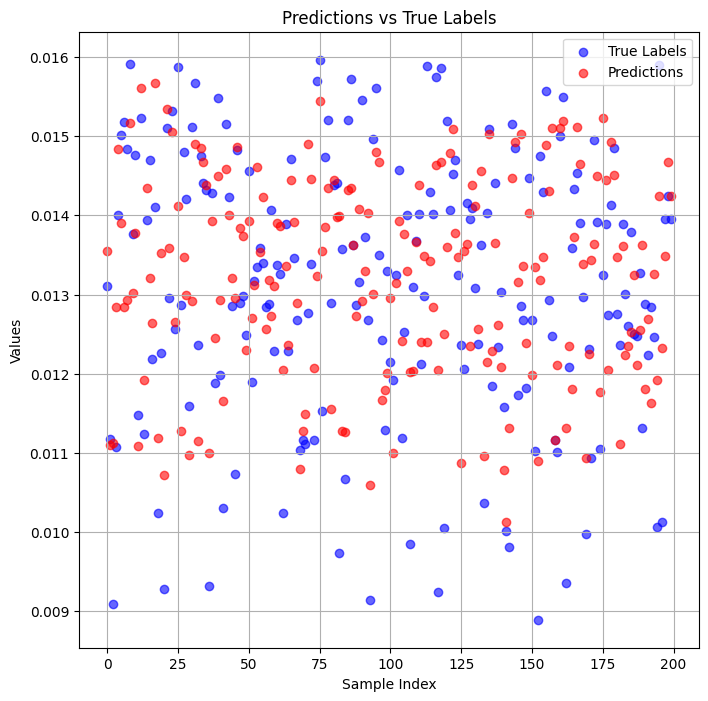

In [56]:
import os
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import QuantileTransformer


# 데이터 매핑 함수
def map_to_numeric(values):
    return {val: idx for idx, val in enumerate(sorted(values))}


# Custom Dataset 정의
class CustomDataset(Dataset):
    def __init__(self, df):
        self.data = df
        self.filtered_data = self.data[self.data['STEP_NAME'] == 'DEPO']
        self.SFQR_AFS2 = self.filtered_data['SFQR_AFS2'].values
        self.quantile_transformer = QuantileTransformer(output_distribution='normal', random_state=42)
        self.labels = self.quantile_transformer.fit_transform(self.SFQR_AFS2.reshape(-1, 1)).flatten()
        self.features = self.filtered_data.drop(
            columns=['SFQR_AFS2', 'STEP_NAME', "WAF_ID", "HST_REG_DTTM", 'STEP_ID']
        ).values

    def __len__(self):
        return len(self.filtered_data)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.features[idx], dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.float32),
        )


# Transformer 모델 정의
class FullMultiLevelTransformer(torch.nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=6, dim_feedforward=128):
        super(FullMultiLevelTransformer, self).__init__()
        self.feature_embedding = torch.nn.Linear(input_dim, d_model)
        self.feature_transformer = torch.nn.TransformerEncoder(
            torch.nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward),
            num_layers=num_layers,
        )
        self.fc = torch.nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.feature_embedding(x)
        x = x.unsqueeze(1)  # (batch_size, seq_len=1, d_model)
        x = self.feature_transformer(x)
        x = x.mean(dim=1)  # (batch_size, d_model)
        return self.fc(x)


# 손실 함수
def mse_loss(output, target):
    return torch.mean((output - target) ** 2)


# 정확도 계산 함수
def calculate_accuracy(output, target, threshold=0.5):
    correct = torch.abs(output - target) <= threshold
    return correct.sum().item() / len(target)


# Train/Validation Split
def train_val_split(dataset, val_ratio=0.2):
    val_size = int(len(dataset) * val_ratio)
    train_size = len(dataset) - val_size
    return random_split(dataset, [train_size, val_size])


# 테스트 함수
def test_model(model, test_loader, device, load_path):
    model.load_state_dict(torch.load(load_path))
    model.to(device)
    model.eval()
    predictions = []
    true_labels = []
    with torch.no_grad():
        for batch_data, batch_labels in tqdm(test_loader, desc="Testing"):
            batch_data = batch_data.to(device)
            batch_labels = batch_labels.to(device)
            outputs = model(batch_data).squeeze()
            predictions.extend(outputs.cpu().numpy())
            true_labels.extend(batch_labels.cpu().numpy())
    return predictions, true_labels


# 그래프 출력 함수
def plot_predictions(predictions, true_labels):
    """
    예측값과 정답값을 비교하는 산점도 생성
    """
    plt.figure(figsize=(8, 8))
    
    # 정답값 (True Labels)
    plt.scatter(
        range(len(true_labels[:200])),
        true_labels[:200],
        alpha=0.6,
        edgecolor="blue",
        label="True Labels",
        color="blue"
    )
    
    # 예측값 (Predictions)
    plt.scatter(
        range(len(predictions[:200])),
        predictions[:200],
        alpha=0.6,
        edgecolor="red",
        label="Predictions",
        color="red"
    )
    
    # 그래프 설정
    plt.title("Predictions vs True Labels")
    plt.xlabel("Sample Index")
    plt.ylabel("Values")
    plt.legend(loc="upper right")
    plt.grid(True)
    plt.show()


# Main 실행
def main():
    # 데이터 경로 설정
    csv_file = 'CENC16B.csv'
    save_path = "model_weights.pth"
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 데이터셋 로드 및 전처리
    df = pd.read_csv(csv_file).dropna()
    df = df.sort_values("HST_REG_DTTM")

    RECIPE_ID = {'CAN3_01_CA', 'CAN3_01_CB', 'CIS_CA', 'CIS_CB', 'CIS_P+_CA', 'CIS_P+_CB', 'CIS_P+_CXT5_CB', 'CIS_P+_GLX5_CA', 'CIS_P+_GLX5_CB', 'CIS_P+_HUA4_CA', 'CIS_P+_HUA4_CB', 'CIS_P+_ICR5_CB', 'CIS_P+_ONS6_CA', 'CIS_P+_ONS6_CB', 'CIS_P+_PSM4_CA', 'CIS_P+_SKH6_CA', 'CIS_P+_SKH6_CB', 'CIS_P+_SKH9_CA',
    'CIS_P+_SKH9_CB', 'CIS_P+_SMI4_CA', 'CIS_P+_UMC4_CA', 'CIS_P+_UMC4_CB', 'CIS_P_SKH6_CA', 'CIS_P_SKH6_CB', 'GF_01_CA', 'GF_01_CB', 'GF_02_CA', 'GF_02_CB', 'GF_03_CA', 'GF_03_CB', 'HUALI_01_CA', 'HUALI_01_CB',
    'INTEL10_CA', 'INTEL10_CB', 'INTEL14_CB', 'INTEL2_CA', 'INTEL2_CB', 'INTEL7_CA', 'INTEL7_CB', 'L2_CB', 'LOG_TSM1_CA', 'LOG_TSM1_CB', 'LOG_TSM3_CA', 'LOG_TSM3_CB', 'MIC_01_CA', 'MIC_01_CB', 'MXIC_01_CA', 'MXIC_01_CB', 'PSMC_02_CA', 'PSMC_02_CB', 'PSMC_FSI_CA', 'S14_CA', 'S14_CB', 'SEC_L58_CA', 'SEC_L58_CB',
    'SKH_CIS_CA', 'SKH_CIS_P+_CA', 'SKH_CIS_P+_CB', 'SL_CA', 'SL_CB', 'SMIC2_R0_CA', 'SMIC2_R0_CB', 'SMIC4_R0_CA', 'SMIC_L7_CB', 'STM_01_CA', 'STM_01_CB', 'STM_P+_CA', 'STM_P+_CB', 'TIX_R0_CA', 'TIX_R0_CB', 'TIX_R1_CA', 'TIX_R1_CB', 'TSMC2_CA', 'TSMC2_CB', 'TSMC_CA', 'TSMC_CB', 'UMC_R0_CA', 'UMC_R0_CB'}

    EQP_ID_MODULE_NAME = {'CENC10A', 'CENC10B', 'CENC11A', 'CENC11B', 'CENC12A', 'CENC12B', 'CENC13A', 'CENC13B', 'CENC14A', 'CENC14B', 'CENC15A', 'CENC15B', 'CENC16A', 'CENC16B', 'CENC17A', 'CENC17B', 'CENC31A', 'CENC31B', 'CENC32A',
    'CENC32B', 'CENC33A', 'CENC33B', 'CENC34A', 'CENC34B', 'CENC35A', 'CENC35B', 'CENC36A', 'CENC36B', 'CENC41A', 'CENC41B', 'CENC42A', 'CENC42B', 'CENC43A', 'CENC43B', 'CENC44A', 'CENC44B', 'CENC45A', 'CENC45B',
    'CENC46A', 'CENC46B', 'CENC47A', 'CENC47B', 'CENC48A', 'CENC48B', 'CENC5A', 'CENC5B', 'CENC6A', 'CENC6B', 'CENC7A', 'CENC7B', 'CENC8A', 'CENC8B', 'CENC9A', 'CENC9B', 'ZCENC01A', 'ZCENC01B', 'ZCENC02A', 'ZCENC02B',
    'ZCENC03A', 'ZCENC03B', 'ZCENC04A', 'ZCENC04B'}

    recipe_mapping = map_to_numeric(RECIPE_ID)
    eqp_mapping = map_to_numeric(EQP_ID_MODULE_NAME)

    csv_file = 'CENC16B.csv'
    df = pd.read_csv(csv_file).dropna()
    df = df.sort_values("HST_REG_DTTM")

    if "RECIPE_ID" in df.columns:
        df["RECIPE_ID"] = df["RECIPE_ID"].map(recipe_mapping)
    if "EQP_ID_MODULE_NAME" in df.columns:
        df["EQP_ID_MODULE_NAME"] = df["EQP_ID_MODULE_NAME"].map(eqp_mapping)

    dataset = CustomDataset(df)
    train_dataset, val_dataset = train_val_split(dataset, val_ratio=0.1)
    test_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)

    # 모델 및 테스트 실행
    model = FullMultiLevelTransformer(input_dim=33, d_model=256, nhead=4, num_layers=2, dim_feedforward=512)
    predictions, true_labels = test_model(model, test_loader, device, save_path)

    predictions = np.array(predictions) 
    true_labels = np.array(true_labels) 

    predictions = quantile_transformer.inverse_transform(predictions.reshape(-1, 1)).flatten()
    true_labels = quantile_transformer.inverse_transform(true_labels.reshape(-1, 1)).flatten()

    
    # 그래프 출력
    plot_predictions(predictions, true_labels)


if __name__ == "__main__":
    main()


/raid/lee/anaconda3/envs/2024/lib/python3.11/site-packages/torch/nn/modules/transformer.py:306: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
Testing: 100%|█████████████████████████████████| 48/48 [00:00<00:00, 168.95it/s]


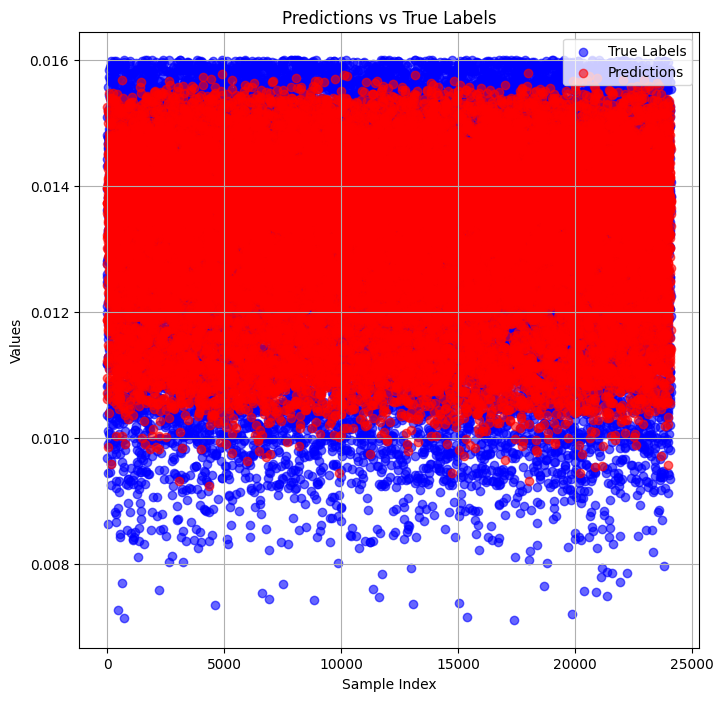

In [55]:
import os
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import QuantileTransformer


# 데이터 매핑 함수
def map_to_numeric(values):
    return {val: idx for idx, val in enumerate(sorted(values))}


# Custom Dataset 정의
class CustomDataset(Dataset):
    def __init__(self, df):
        self.data = df
        self.filtered_data = self.data[self.data['STEP_NAME'] == 'DEPO']
        self.SFQR_AFS2 = self.filtered_data['SFQR_AFS2'].values
        self.quantile_transformer = QuantileTransformer(output_distribution='normal', random_state=42)
        self.labels = self.quantile_transformer.fit_transform(self.SFQR_AFS2.reshape(-1, 1)).flatten()
        self.features = self.filtered_data.drop(
            columns=['SFQR_AFS2', 'STEP_NAME', "WAF_ID", "HST_REG_DTTM", 'STEP_ID']
        ).values

    def __len__(self):
        return len(self.filtered_data)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.features[idx], dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.float32),
        )


# Transformer 모델 정의
class FullMultiLevelTransformer(torch.nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=6, dim_feedforward=128):
        super(FullMultiLevelTransformer, self).__init__()
        self.feature_embedding = torch.nn.Linear(input_dim, d_model)
        self.feature_transformer = torch.nn.TransformerEncoder(
            torch.nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward),
            num_layers=num_layers,
        )
        self.fc = torch.nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.feature_embedding(x)
        x = x.unsqueeze(1)  # (batch_size, seq_len=1, d_model)
        x = self.feature_transformer(x)
        x = x.mean(dim=1)  # (batch_size, d_model)
        return self.fc(x)


# 손실 함수
def mse_loss(output, target):
    return torch.mean((output - target) ** 2)


# 정확도 계산 함수
def calculate_accuracy(output, target, threshold=0.5):
    correct = torch.abs(output - target) <= threshold
    return correct.sum().item() / len(target)


# Train/Validation Split
def train_val_split(dataset, val_ratio=0.2):
    val_size = int(len(dataset) * val_ratio)
    train_size = len(dataset) - val_size
    return random_split(dataset, [train_size, val_size])


# 테스트 함수
def test_model(model, test_loader, device, load_path):
    model.load_state_dict(torch.load(load_path))
    model.to(device)
    model.eval()
    predictions = []
    true_labels = []
    with torch.no_grad():
        for batch_data, batch_labels in tqdm(test_loader, desc="Testing"):
            batch_data = batch_data.to(device)
            batch_labels = batch_labels.to(device)
            outputs = model(batch_data).squeeze()
            predictions.extend(outputs.cpu().numpy())
            true_labels.extend(batch_labels.cpu().numpy())
    return predictions, true_labels


# 그래프 출력 함수
def plot_predictions(predictions, true_labels):
    """
    예측값과 정답값을 비교하는 산점도 생성
    """
    plt.figure(figsize=(8, 8))
    
    # 정답값 (True Labels)
    plt.scatter(
        range(len(true_labels)),
        true_labels,
        alpha=0.6,
        edgecolor="blue",
        label="True Labels",
        color="blue"
    )
    
    # 예측값 (Predictions)
    plt.scatter(
        range(len(predictions)),
        predictions,
        alpha=0.6,
        edgecolor="red",
        label="Predictions",
        color="red"
    )
    
    # 그래프 설정
    plt.title("Predictions vs True Labels")
    plt.xlabel("Sample Index")
    plt.ylabel("Values")
    plt.legend(loc="upper right")
    plt.grid(True)
    plt.show()


# Main 실행
def main():
    # 데이터 경로 설정
    csv_file = 'CENC16B.csv'
    save_path = "model_weights.pth"
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 데이터셋 로드 및 전처리
    df = pd.read_csv(csv_file).dropna()
    df = df.sort_values("HST_REG_DTTM")

    RECIPE_ID = {'CAN3_01_CA', 'CAN3_01_CB', 'CIS_CA', 'CIS_CB', 'CIS_P+_CA', 'CIS_P+_CB', 'CIS_P+_CXT5_CB', 'CIS_P+_GLX5_CA', 'CIS_P+_GLX5_CB', 'CIS_P+_HUA4_CA', 'CIS_P+_HUA4_CB', 'CIS_P+_ICR5_CB', 'CIS_P+_ONS6_CA', 'CIS_P+_ONS6_CB', 'CIS_P+_PSM4_CA', 'CIS_P+_SKH6_CA', 'CIS_P+_SKH6_CB', 'CIS_P+_SKH9_CA',
    'CIS_P+_SKH9_CB', 'CIS_P+_SMI4_CA', 'CIS_P+_UMC4_CA', 'CIS_P+_UMC4_CB', 'CIS_P_SKH6_CA', 'CIS_P_SKH6_CB', 'GF_01_CA', 'GF_01_CB', 'GF_02_CA', 'GF_02_CB', 'GF_03_CA', 'GF_03_CB', 'HUALI_01_CA', 'HUALI_01_CB',
    'INTEL10_CA', 'INTEL10_CB', 'INTEL14_CB', 'INTEL2_CA', 'INTEL2_CB', 'INTEL7_CA', 'INTEL7_CB', 'L2_CB', 'LOG_TSM1_CA', 'LOG_TSM1_CB', 'LOG_TSM3_CA', 'LOG_TSM3_CB', 'MIC_01_CA', 'MIC_01_CB', 'MXIC_01_CA', 'MXIC_01_CB', 'PSMC_02_CA', 'PSMC_02_CB', 'PSMC_FSI_CA', 'S14_CA', 'S14_CB', 'SEC_L58_CA', 'SEC_L58_CB',
    'SKH_CIS_CA', 'SKH_CIS_P+_CA', 'SKH_CIS_P+_CB', 'SL_CA', 'SL_CB', 'SMIC2_R0_CA', 'SMIC2_R0_CB', 'SMIC4_R0_CA', 'SMIC_L7_CB', 'STM_01_CA', 'STM_01_CB', 'STM_P+_CA', 'STM_P+_CB', 'TIX_R0_CA', 'TIX_R0_CB', 'TIX_R1_CA', 'TIX_R1_CB', 'TSMC2_CA', 'TSMC2_CB', 'TSMC_CA', 'TSMC_CB', 'UMC_R0_CA', 'UMC_R0_CB'}

    EQP_ID_MODULE_NAME = {'CENC10A', 'CENC10B', 'CENC11A', 'CENC11B', 'CENC12A', 'CENC12B', 'CENC13A', 'CENC13B', 'CENC14A', 'CENC14B', 'CENC15A', 'CENC15B', 'CENC16A', 'CENC16B', 'CENC17A', 'CENC17B', 'CENC31A', 'CENC31B', 'CENC32A',
    'CENC32B', 'CENC33A', 'CENC33B', 'CENC34A', 'CENC34B', 'CENC35A', 'CENC35B', 'CENC36A', 'CENC36B', 'CENC41A', 'CENC41B', 'CENC42A', 'CENC42B', 'CENC43A', 'CENC43B', 'CENC44A', 'CENC44B', 'CENC45A', 'CENC45B',
    'CENC46A', 'CENC46B', 'CENC47A', 'CENC47B', 'CENC48A', 'CENC48B', 'CENC5A', 'CENC5B', 'CENC6A', 'CENC6B', 'CENC7A', 'CENC7B', 'CENC8A', 'CENC8B', 'CENC9A', 'CENC9B', 'ZCENC01A', 'ZCENC01B', 'ZCENC02A', 'ZCENC02B',
    'ZCENC03A', 'ZCENC03B', 'ZCENC04A', 'ZCENC04B'}

    recipe_mapping = map_to_numeric(RECIPE_ID)
    eqp_mapping = map_to_numeric(EQP_ID_MODULE_NAME)

    csv_file = 'CENC16B.csv'
    df = pd.read_csv(csv_file).dropna()
    df = df.sort_values("HST_REG_DTTM")

    if "RECIPE_ID" in df.columns:
        df["RECIPE_ID"] = df["RECIPE_ID"].map(recipe_mapping)
    if "EQP_ID_MODULE_NAME" in df.columns:
        df["EQP_ID_MODULE_NAME"] = df["EQP_ID_MODULE_NAME"].map(eqp_mapping)

    dataset = CustomDataset(df)
    train_dataset, val_dataset = train_val_split(dataset, val_ratio=1)
    test_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)

    # 모델 및 테스트 실행
    model = FullMultiLevelTransformer(input_dim=33, d_model=256, nhead=4, num_layers=2, dim_feedforward=512)
    predictions, true_labels = test_model(model, test_loader, device, save_path)

    predictions = np.array(predictions) 
    true_labels = np.array(true_labels) 

    predictions = quantile_transformer.inverse_transform(predictions.reshape(-1, 1)).flatten()
    true_labels = quantile_transformer.inverse_transform(true_labels.reshape(-1, 1)).flatten()

    
    # 그래프 출력
    plot_predictions(predictions, true_labels)


if __name__ == "__main__":
    main()
